# Customer Behavior Segmentation Using Data Analytics

## Objective
The objective of this project is to analyze customer behavioral data and identify distinct customer segments using data-driven techniques. The segmentation will help in understanding spending behavior, engagement patterns, and potential strategic business actions.

## Introduction

Customer segmentation is a strategic technique used by businesses to divide customers into distinct groups based on behavioral and financial characteristics. Identifying meaningful segments enables targeted marketing, improved retention strategies, and optimized resource allocation.

In this project, we apply data cleaning, exploratory analysis, feature engineering, and clustering techniques to segment customers based on their behavioral attributes.

In [1]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 6.3 MB/s  0:00:01 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 4.1 MB/s  0:00:05m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 300

data = {
    "customer_id": range(1, n+1),
    "age": np.random.randint(18, 60, n),
    "gender": np.random.choice(["Male", "Female"], n),
    "annual_income": np.random.normal(60000, 15000, n),
    "spending_score": np.random.randint(1, 100, n),
    "purchase_frequency": np.random.randint(1, 20, n),
    "avg_transaction_value": np.random.normal(200, 50, n),
    "product_category": np.random.choice(["Electronics", "Clothing", "Home", "Sports"], n),
    "tenure_months": np.random.randint(1, 60, n),
    "online_engagement_score": np.random.randint(1, 100, n),
    "returns_ratio": np.random.uniform(0, 0.5, n)
}

df = pd.DataFrame(data)

# Introduce missing values
df.loc[np.random.choice(df.index, 20), "annual_income"] = np.nan
df.loc[np.random.choice(df.index, 15), "online_engagement_score"] = np.nan

# Save as CSV
df.to_csv("../data/customer_data.csv", index=False)

df.head()

,customer_id,age,gender,annual_income,spending_score,purchase_frequency,avg_transaction_value,product_category,tenure_months,online_engagement_score,returns_ratio
0,1,56,Male,66729.730111,27,12,255.183347,Electronics,16,64.0,0.046704
1,2,46,Female,58819.024745,36,13,286.270814,Electronics,33,98.0,0.220536
2,3,32,Male,26748.584183,29,7,168.546401,Clothing,4,89.0,0.097805
3,4,25,Male,80843.495079,38,10,191.572206,Sports,4,10.0,0.093362
4,5,38,Female,88056.358467,57,13,177.541810,Electronics,39,21.0,0.047018


In [3]:
import os
os.getcwd()

'/Users/plabonroy/program/Data-analytics-project/Customer_Segmentation_Project/notebooks'

In [6]:
df = pd.read_csv("../data/customer_data.csv")

## Data Understanding

In this section, we examine the structure, data types, summary statistics, and missing values in the dataset. This helps identify potential data quality issues before performing any transformation.

In [7]:
df.shape

(300, 11)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              300 non-null    int64  
 1   age                      300 non-null    int64  
 2   gender                   300 non-null    object 
 3   annual_income            280 non-null    float64
 4   spending_score           300 non-null    int64  
 5   purchase_frequency       300 non-null    int64  
 6   avg_transaction_value    300 non-null    float64
 7   product_category         300 non-null    object 
 8   tenure_months            300 non-null    int64  
 9   online_engagement_score  286 non-null    float64
 10  returns_ratio            300 non-null    float64
dtypes: float64(4), int64(5), object(2)
memory usage: 25.9+ KB


In [9]:
df.describe()

,customer_id,age,annual_income,spending_score,purchase_frequency,avg_transaction_value,tenure_months,online_engagement_score,returns_ratio
count,300.000000,300.000000,280.000000,300.000000,300.000000,300.000000,300.000000,286.000000,300.000000
mean,150.500000,38.990000,60108.395605,49.350000,10.186667,207.315421,29.930000,51.000000,0.247791
std,86.746758,12.408187,16054.713221,28.745699,5.380986,52.995737,16.470053,27.930616,0.148103
min,1.000000,18.000000,9538.567103,1.000000,1.000000,69.507910,1.000000,1.000000,0.000094
25%,75.750000,28.000000,49470.032082,26.750000,5.000000,172.641871,17.000000,26.000000,0.118844
50%,150.500000,40.000000,60882.344019,47.500000,10.000000,207.020311,30.000000,53.500000,0.238340
75%,225.250000,50.000000,71464.092747,74.000000,15.000000,245.276286,44.000000,74.000000,0.378962
max,300.000000,59.000000,93126.757888,99.000000,19.000000,355.243371,59.000000,99.000000,0.498539


In [10]:
df.isnull().sum()

customer_id                 0
age                         0
gender                      0
annual_income              20
spending_score              0
purchase_frequency          0
avg_transaction_value       0
product_category            0
tenure_months               0
online_engagement_score    14
returns_ratio               0
dtype: int64

## Data Overview

The dataset consists of 300 customer records with 11 variables capturing demographic, financial, and behavioral attributes.

Initial inspection reveals missing values in two variables:
- `annual_income` (20 missing values)
- `online_engagement_score` (14 missing values)

The proportion of missing data is relatively small (below 10%), suggesting that appropriate imputation strategies can be applied without significantly compromising analytical integrity.

The dataset appears structurally suitable for customer segmentation analysis.

## Missing Value Treatment

The dataset contains missing values in two variables: `annual_income` and `online_engagement_score`.

Since income distributions often contain outliers, the median value is used to impute missing values in `annual_income` to avoid distortion caused by extreme values.

For `online_engagement_score`, the mean value is used for imputation because engagement scores are bounded within a smaller range and are less sensitive to outliers.

In [11]:
df["annual_income"].fillna(df["annual_income"].median(), inplace=True)

df["online_engagement_score"].fillna(df["online_engagement_score"].mean(), inplace=True)

In [12]:
df.isnull().sum()

customer_id                0
age                        0
gender                     0
annual_income              0
spending_score             0
purchase_frequency         0
avg_transaction_value      0
product_category           0
tenure_months              0
online_engagement_score    0
returns_ratio              0
dtype: int64

## Outlier Detection

Before applying clustering algorithms, it is important to examine the dataset for potential outliers. Since clustering methods rely on distance calculations, extreme values can significantly influence cluster formation. Boxplots are used to visually inspect numerical variables for the presence of outliers.

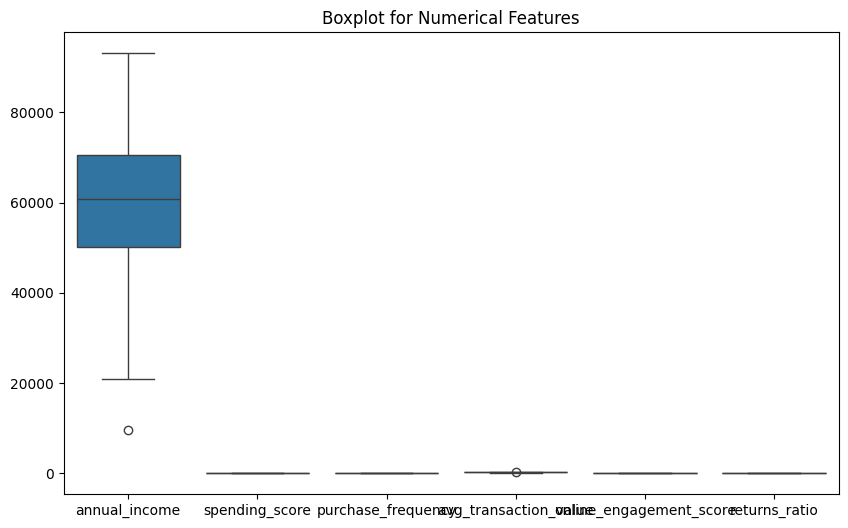

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.boxplot(data=df[[
    "annual_income",
    "spending_score",
    "purchase_frequency",
    "avg_transaction_value",
    "online_engagement_score",
    "returns_ratio"
]])

plt.title("Boxplot for Numerical Features")
plt.show()

### Interpretation

From the boxplot visualization, `annual_income` and `avg_transaction_value` display noticeable extreme values outside the typical range of the dataset.

These values indicate potential outliers that could influence clustering results. Since clustering algorithms such as KMeans rely on distance calculations, extreme values may disproportionately affect cluster formation.

Therefore, it is important to further evaluate whether these outliers represent legitimate customer behavior or whether they require treatment before proceeding with clustering.

## Outlier Detection using IQR Method

To systematically identify outliers, the Interquartile Range (IQR) method is used. The IQR measures the spread of the middle 50% of the data and helps in detecting values that fall significantly outside this range.

Outliers are defined as values that lie below Q1 - 1.5×IQR or above Q3 + 1.5×IQR.

In [14]:
Q1 = df["annual_income"].quantile(0.25)
Q3 = df["annual_income"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_income = df[(df["annual_income"] < lower_bound) | (df["annual_income"] > upper_bound)]

len(outliers_income)

1

### Interpretation

Using the IQR method, only one outlier was detected in the `annual_income` variable.

Given the small number of outliers and the possibility that this value represents a high-income customer, it is reasonable to retain this data point. Removing such values may lead to loss of important information, especially in customer segmentation tasks where high-value customers are significant.

Therefore, no outlier treatment is applied to the `annual_income` variable.

## Categorical Variable Encoding

The dataset contains categorical variables such as `gender` and `product_category`, which cannot be directly used in clustering algorithms.

To convert these variables into a numerical format, one-hot encoding is applied. This method creates binary columns for each category, ensuring that no artificial ordering is introduced between categories.

This approach is preferred over label encoding, as clustering algorithms rely on distance calculations and should not assume any ordinal relationship between categorical values.

In [23]:
df = pd.read_csv("../data/customer_data.csv")

df = pd.get_dummies(df, columns=["gender", "product_category"], drop_first=True)

In [24]:
df.isnull().sum()

customer_id                      0
age                              0
annual_income                   20
spending_score                   0
purchase_frequency               0
avg_transaction_value            0
tenure_months                    0
online_engagement_score         14
returns_ratio                    0
gender_Male                      0
product_category_Electronics     0
product_category_Home            0
product_category_Sports          0
dtype: int64

In [25]:
df = df.apply(lambda x: x.astype(int) if x.dtype == 'bool' else x)

In [26]:
df.head()

,customer_id,age,annual_income,spending_score,purchase_frequency,avg_transaction_value,tenure_months,online_engagement_score,returns_ratio,gender_Male,product_category_Electronics,product_category_Home,product_category_Sports
0,1,56,66729.730111,27,12,255.183347,16,64.0,0.046704,1,1,0,0
1,2,46,58819.024745,36,13,286.270814,33,98.0,0.220536,0,1,0,0
2,3,32,26748.584183,29,7,168.546401,4,89.0,0.097805,1,0,0,0
3,4,25,80843.495079,38,10,191.572206,4,10.0,0.093362,1,0,0,1
4,5,38,88056.358467,57,13,177.541810,39,21.0,0.047018,0,1,0,0


### Interpretation

After applying one-hot encoding, categorical variables were successfully transformed into numerical format. A total of four new binary columns were created.

The resulting variables are now suitable for clustering, as all features are in numerical form. Boolean values were converted into 0 and 1 to ensure consistency and compatibility with further analysis.

## Feature Engineering

Feature engineering is performed to create more meaningful variables that better represent customer behavior.

A new feature, `customer_value`, is created by multiplying purchase frequency with average transaction value. This variable serves as a proxy for the overall revenue contribution of each customer.

In [27]:
df["customer_value"] = df["purchase_frequency"] * df["avg_transaction_value"]

In [28]:
df[["purchase_frequency", "avg_transaction_value", "customer_value"]].head()

,purchase_frequency,avg_transaction_value,customer_value
0,12,255.183347,3062.200166
1,13,286.270814,3721.520579
2,7,168.546401,1179.824810
3,10,191.572206,1915.722063
4,13,177.541810,2308.043524
